# CLV Segmentation and Campaign ROI

Operationalizes CLV predictions into actionable business outputs:

1. **4-tier customer segmentation** based on predicted CLV and P(purchase)
2. **Segment profiles**: size, avg CLV, predicted revenue, recommended actions
3. **Campaign ROI allocation table**: budget optimization by segment

**Outputs:**
- `data/processed/clv_final.csv` — customers with segments and all CLV features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
SCORED_PATH = "../data/processed/clv_scored.csv"
FINAL_PATH  = "../data/processed/clv_final.csv"

## 1. Load Data

In [2]:
df = pd.read_csv(SCORED_PATH)
print(f"Loaded {len(df):,} customers x {df.shape[1]} features")
print(f"\nCLV (12m) range: ${df['clv_12m'].min():.2f} — ${df['clv_12m'].max():.2f}")
print(f"p_purchase range: {df['p_purchase'].min():.4f} — {df['p_purchase'].max():.4f}")

Loaded 52,507 customers x 40 features

CLV (12m) range: $0.00 — $134.52
p_purchase range: 0.0000 — 0.6987


## 2. 4-Tier Customer Segmentation

| Segment | Definition | Recommended Action |
|---------|------------|--------------------|
| **High Value** | Top 20% CLV | No discounts — protect margin |
| **At-Risk** | p_purchase < 0.05 (any CLV band) | Win-back campaign |
| **Growing** | Middle 40% CLV + p_purchase >= 0.05 | Personalized offers |
| **Low Value** | Bottom 40% CLV + p_purchase >= 0.05 | Email-only, minimal spend |

**Note:** At-Risk is checked across all CLV bands (except High Value) and takes priority over Growing/Low Value. The threshold of 0.05 is well below the 12.3% base purchase rate.

In [3]:
# Define CLV thresholds
P_PURCHASE_ATRISK = 0.05

clv_top20_threshold    = df['clv_12m'].quantile(0.80)
clv_bottom40_threshold = df['clv_12m'].quantile(0.40)

print(f"Segmentation thresholds:")
print(f"  Top 20% (High Value):   CLV > ${clv_top20_threshold:.2f}")
print(f"  Middle 40% (Growing):   ${clv_bottom40_threshold:.2f} < CLV <= ${clv_top20_threshold:.2f}")
print(f"  Bottom 40% (Low Value): CLV <= ${clv_bottom40_threshold:.2f}")
print(f"  At-Risk:                p_purchase < {P_PURCHASE_ATRISK} (overrides Growing/Low Value)")

def assign_segment(row):
    if row['clv_12m'] > clv_top20_threshold:
        return 'High Value'
    elif row['p_purchase'] < P_PURCHASE_ATRISK:
        return 'At-Risk'
    elif row['clv_12m'] > clv_bottom40_threshold:
        return 'Growing'
    else:
        return 'Low Value'

df['segment'] = df.apply(assign_segment, axis=1)

segment_counts = df['segment'].value_counts()
print(f"\nSegment distribution:")
for seg, cnt in segment_counts.items():
    print(f"  {seg:15s}: {cnt:,} customers ({cnt/len(df):.1%})")

Segmentation thresholds:
  Top 20% (High Value):   CLV > $32.99
  Middle 40% (Growing):   $17.28 < CLV <= $32.99
  Bottom 40% (Low Value): CLV <= $17.28
  At-Risk:                p_purchase < 0.05 (overrides Growing/Low Value)

Segment distribution:
  Growing        : 21,003 customers (40.0%)
  Low Value      : 19,364 customers (36.9%)
  High Value     : 10,501 customers (20.0%)
  At-Risk        : 1,639 customers (3.1%)


## 3. Segment Profiles

In [4]:
seg_order = ['High Value', 'Growing', 'At-Risk', 'Low Value']

seg_profile = df.groupby('segment').agg(
    n_customers        = ('user_id', 'count'),
    avg_clv_12m        = ('clv_12m', 'mean'),
    median_clv_12m     = ('clv_12m', 'median'),
    total_pred_revenue = ('clv_12m', 'sum'),
    avg_p_purchase     = ('p_purchase', 'mean'),
    avg_frequency      = ('frequency', 'mean'),
    avg_monetary       = ('monetary_value', 'mean'),
).round(2)

seg_profile['revenue_share'] = (seg_profile['total_pred_revenue'] / seg_profile['total_pred_revenue'].sum() * 100).round(1)

seg_profile = seg_profile.reindex([s for s in seg_order if s in seg_profile.index])

print("=== Segment Profile ===")
print(seg_profile.to_string())

=== Segment Profile ===
            n_customers  avg_clv_12m  median_clv_12m  total_pred_revenue  avg_p_purchase  avg_frequency  avg_monetary  revenue_share
segment                                                                                                                             
High Value        10501        44.92           42.43           471741.57            0.23           0.67         78.39           37.8
Growing           21003        23.37           22.72           490794.30            0.12           0.30         85.46           39.3
At-Risk            1639         1.37            0.00             2252.79            0.01           2.62         95.45            0.2
Low Value         19364        14.62           14.98           283051.29            0.08           0.24         91.40           22.7


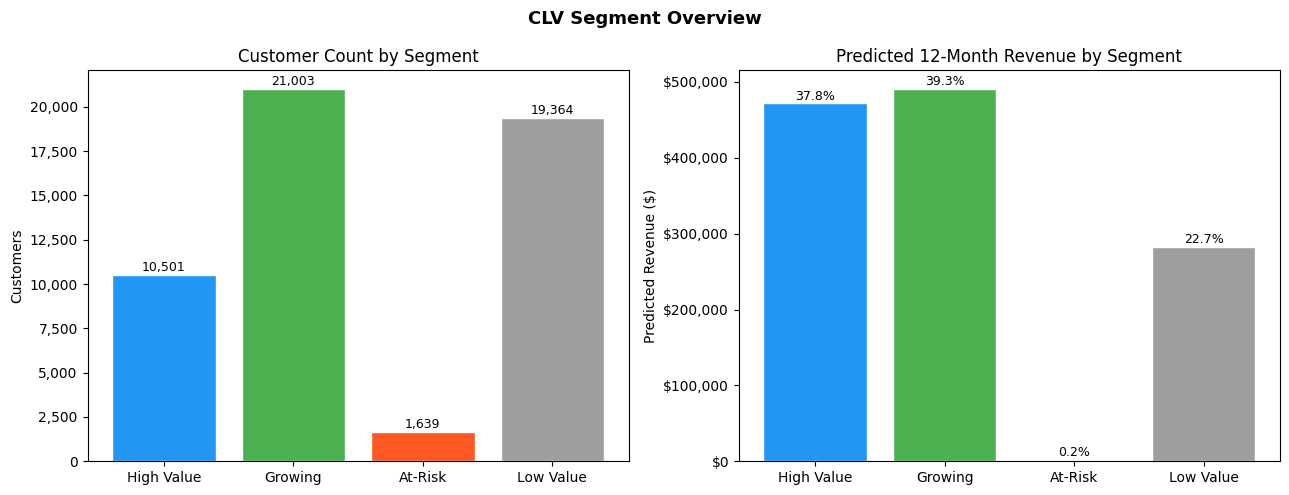

In [5]:
# Segment visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'High Value': '#2196F3', 'Growing': '#4CAF50', 'At-Risk': '#FF5722', 'Low Value': '#9E9E9E'}
segs = [s for s in seg_order if s in seg_profile.index]

# Customer count by segment
counts = [seg_profile.loc[s, 'n_customers'] for s in segs]
bar_colors = [colors[s] for s in segs]
axes[0].bar(segs, counts, color=bar_colors, edgecolor='white')
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts)*0.01, f'{v:,}', ha='center', fontsize=9)

# Predicted revenue by segment
revenues = [seg_profile.loc[s, 'total_pred_revenue'] for s in segs]
axes[1].bar(segs, revenues, color=bar_colors, edgecolor='white')
axes[1].set_title('Predicted 12-Month Revenue by Segment')
axes[1].set_ylabel('Predicted Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (v, s) in enumerate(zip(revenues, segs)):
    share = seg_profile.loc[s, 'revenue_share']
    axes[1].text(i, v + max(revenues)*0.01, f'{share:.1f}%', ha='center', fontsize=9)

plt.suptitle('CLV Segment Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Campaign ROI Allocation Table

| Segment | Budget/Customer | Conversion Rate | Rationale |
|---------|----------------|-----------------|----------|
| High Value | $0 (organic) | 40% | Retain naturally; discounts destroy margin |
| Growing | $15 | 25% | Personalized offer justified by growth potential |
| At-Risk | $10 | 15% | Win-back campaign; lower success rate |
| Low Value | $2 (email) | 5% | Email only; minimum investment |

In [6]:
campaign_params = {
    'High Value': {'budget_per_customer': 0,  'conversion_rate': 0.40, 'action': 'VIP loyalty — no campaign'},
    'Growing':    {'budget_per_customer': 15, 'conversion_rate': 0.25, 'action': 'Personalized offer'},
    'At-Risk':    {'budget_per_customer': 10, 'conversion_rate': 0.15, 'action': 'Win-back campaign'},
    'Low Value':  {'budget_per_customer': 2,  'conversion_rate': 0.05, 'action': 'Email only'},
}

roi_rows = []
for seg in seg_order:
    if seg not in seg_profile.index:
        continue
    params   = campaign_params[seg]
    n_cust   = seg_profile.loc[seg, 'n_customers']
    avg_clv  = seg_profile.loc[seg, 'avg_clv_12m']
    budget   = params['budget_per_customer']
    conv     = params['conversion_rate']

    total_cost    = budget * n_cust
    expected_rev  = avg_clv * conv * n_cust
    net_roi       = expected_rev - total_cost
    roi_pct       = (net_roi / total_cost * 100) if total_cost > 0 else float('inf')

    roi_rows.append({
        'Segment':             seg,
        'Customers':           n_cust,
        'Budget/Customer':     f'${budget}',
        'Conversion Rate':     f'{conv:.0%}',
        'Avg CLV':             f'${avg_clv:,.2f}',
        'Total Campaign Cost': f'${total_cost:,.0f}',
        'Expected Revenue':    f'${expected_rev:,.0f}',
        'Net ROI':             f'${net_roi:,.0f}',
        'ROI %':               f'{roi_pct:.0f}%' if total_cost > 0 else 'N/A (no spend)',
        'Action':              params['action'],
    })

roi_df = pd.DataFrame(roi_rows)
print("=== Campaign ROI Allocation Table ===")
print(roi_df.to_string(index=False))

=== Campaign ROI Allocation Table ===
   Segment  Customers Budget/Customer Conversion Rate Avg CLV Total Campaign Cost Expected Revenue   Net ROI          ROI %                    Action
High Value      10501              $0             40%  $44.92                  $0         $188,682  $188,682 N/A (no spend) VIP loyalty — no campaign
   Growing      21003             $15             25%  $23.37            $315,045         $122,710 $-192,335           -61%        Personalized offer
   At-Risk       1639             $10             15%   $1.37             $16,390             $337  $-16,053           -98%         Win-back campaign
 Low Value      19364              $2              5%  $14.62             $38,728          $14,155  $-24,573           -63%                Email only


## 5. Save Final Outputs

In [7]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv(FINAL_PATH, index=False)
print(f"Final CLV data saved to {FINAL_PATH}")
print(f"  Shape: {df.shape[0]:,} customers x {df.shape[1]} columns")
print(f"  Key columns: segment, clv_12m, p_purchase, spend_tier")

Final CLV data saved to ../data/processed/clv_final.csv
  Shape: 52,507 customers x 41 columns
  Key columns: segment, clv_12m, p_purchase, spend_tier


In [8]:
print("=" * 55)
print("CLV SEGMENTATION SUMMARY")
print("=" * 55)
print(f"Total customers:      {len(df):,}")
print(f"Total predicted CLV:  ${df['clv_12m'].sum():,.0f}")
print(f"Median CLV:           ${df['clv_12m'].median():.2f}")
print()
for seg in seg_order:
    if seg in seg_profile.index:
        n   = int(seg_profile.loc[seg, 'n_customers'])
        rev = seg_profile.loc[seg, 'total_pred_revenue']
        pct = seg_profile.loc[seg, 'revenue_share']
        print(f"  {seg:15s}: {n:,} customers | ${rev:>10,.0f} predicted ({pct:.1f}%)")
print("=" * 55)
print("\nNext step: streamlit run src/app.py")

CLV SEGMENTATION SUMMARY
Total customers:      52,507
Total predicted CLV:  $1,247,840
Median CLV:           $19.50

  High Value     : 10,501 customers | $   471,742 predicted (37.8%)
  Growing        : 21,003 customers | $   490,794 predicted (39.3%)
  At-Risk        : 1,639 customers | $     2,253 predicted (0.2%)
  Low Value      : 19,364 customers | $   283,051 predicted (22.7%)

Next step: streamlit run src/app.py
